# K-Means Clustering on the Iris Dataset
**Author:** @VedantAndhale

## 1. Import Required Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

## 2. Load and Preview the Iris Dataset

In [8]:
# Load the Iris dataset
iris = load_iris()
data = iris.data
feature_names = iris.feature_names

# Convert to DataFrame for easier exploration
iris_df = pd.DataFrame(data, columns=feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Standardize the Data

In [9]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

## 4. Determine the Optimal Number of Clusters (Elbow Method)

In [ ]:
# Initialize an empty list to store the values of the within-cluster sum of squares (WCSS)
wcss = []

# Determine the number of clusters using the elbow method
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", max_iter=30, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

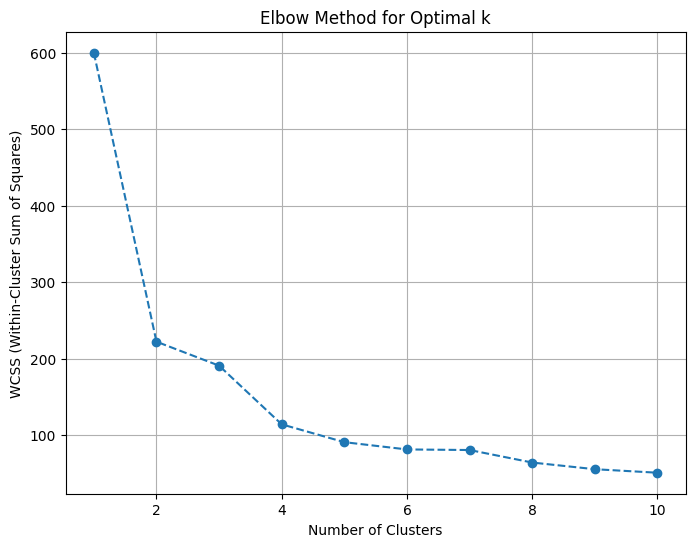

In [ ]:
# Plot the elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid()
plt.show()

## 5. Apply K-Means with Optimal k and Visualize Clusters

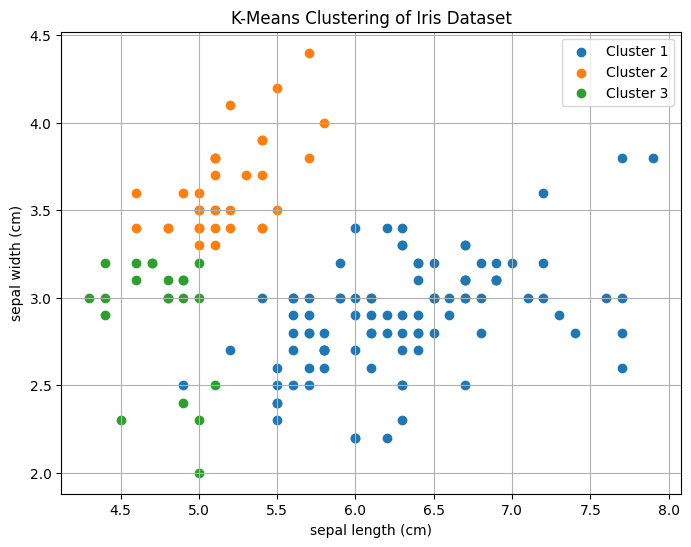

In [ ]:
# Fit KMeans with k=3
kmeans = KMeans(n_clusters=3, init="k-means++", max_iter=30, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Add cluster labels to DataFrame
iris_df["Cluster"] = clusters

# Visualize clusters using the first two features
plt.figure(figsize=(8, 6))
for cluster in range(3):
    plt.scatter(
        iris_df[iris_df["Cluster"] == cluster][feature_names[0]],
        iris_df[iris_df["Cluster"] == cluster][feature_names[1]],
        label=f"Cluster {cluster + 1}",
    )
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("K-Means Clustering of Iris Dataset")
plt.legend()
plt.grid()
plt.show()